# Tutorial 33 — BC2N: k.p expansion coefficients (postw90 `kdotp`)

The waw-native reimagining of Wannier90 tutorial 33. A **BC2N** nanoribbon/slab (periodic along $x$ and $z$, a 20 Å vacuum gap along $y$) has a 4-orbital $\pi$-manifold built from a single $p_y$ orbital per atom (B, C, C, N -- $p_y$ points out of the sheet, the same role $p_z$ plays in graphene). This notebook builds those 4 MLWFs, then uses a genuinely new capability, `waw.analysis.kdotp.kdotp_coefficients`, to expand the Wannier-interpolated Hamiltonian to 2nd order in $k$ around the S point ($\mathbf{k}=(\tfrac12,0,\tfrac12)$) via quasi-degenerate (Löwdin) perturbation theory -- transcribed directly from wannier90's own `berry_get_kdotp` (`src/postw90/berry.F90`). The result is a compact $2\times2$ effective Hamiltonian for the two "interesting" Wannier bands at that point, reconstructed and checked against the true interpolated dispersion nearby.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and a genuine `ecutwfc` convergence check
$a=2.466$ Å, $c=4.323$ Å, 20 Å vacuum along $y$ -- the real tutorial's own lattice, atoms in the same Cartesian positions. This project's PseudoDojo B/C/N pseudopotentials are valence-only (3+4+5 electrons, no semicore), unlike the real tutorial's own PAW pseudopotentials (which is why that tutorial's own `num_bands=29`/`exclude_bands`/`fermi_energy` are not reused here -- they are artifacts of a different pseudopotential). `ecutwfc` is converged from scratch below, on the real SCF total energy, rather than just guessed.

In [2]:
from ase import Atoms
a, vac, c = 2.466, 20.00, 4.323
cell = [[a, 0.0, 0.0], [0.0, vac, 0.0], [0.0, 0.0, c]]
symbols = ['B', 'C', 'C', 'N']
pos_cart = [[1.2330000, 0.0000000, 1.1830592],
            [1.2330000, 0.0000000, 2.6963492],
            [0.0000000, 0.0000000, 3.3885933],
            [0.0000000, 0.0000000, 4.7677273]]
atoms = Atoms(symbols, positions=pos_cart, cell=cell, pbc=True)
MP_GRID = (10, 1, 10)
WORK = HERE / 'runs' / 'bc2n'
PSEUDOS = {'B': 'B.upf', 'C': 'C.upf', 'N': 'N.upf'}
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.02)

import re
conv_dir = WORK / 'ecutwfc_scan'
conv_dir.mkdir(parents=True, exist_ok=True)
energies = {}
for ecut in (40, 50, 60, 70, 80):
    d = conv_dir / f'ecut{ecut}'; d.mkdir(exist_ok=True); (d / 'out').mkdir(exist_ok=True)
    inp = qe.write_pw_input(
        d / 'scf.in', atoms,
        control=dict(calculation='scf', prefix='bc2n', pseudo_dir=str(PSEUDO_DIR), outdir='./out'),
        system=dict(ecutwfc=ecut, **SMEAR),
        electrons=dict(conv_thr=1e-8, mixing_beta=0.4),
        pseudopotentials=PSEUDOS, kpoints=('automatic', MP_GRID, (0, 0, 0)),
    )
    out = qe.run_pw(inp, d / 'scf.out', ncores=NCORES)
    m = re.findall(r'!\s+total energy\s+=\s+([-\d.]+) Ry', out.read_text())
    energies[ecut] = float(m[-1])
    print(f'ecutwfc={ecut:3d} Ry   E_tot = {energies[ecut]:.6f} Ry')

ecuts = sorted(energies)
for e1, e2 in zip(ecuts[:-1], ecuts[1:]):
    print(f'  {e1:3d} -> {e2:3d} Ry : dE = {(energies[e2]-energies[e1])*1000:+.3f} mRy '
          f'({(energies[e2]-energies[e1])*1000/len(atoms):+.3f} mRy/atom)')

ecutwfc= 40 Ry   E_tot = -50.645468 Ry


ecutwfc= 50 Ry   E_tot = -50.790446 Ry


ecutwfc= 60 Ry   E_tot = -50.830756 Ry


ecutwfc= 70 Ry   E_tot = -50.840167 Ry


ecutwfc= 80 Ry   E_tot = -50.841947 Ry
   40 ->  50 Ry : dE = -144.977 mRy (-36.244 mRy/atom)
   50 ->  60 Ry : dE = -40.311 mRy (-10.078 mRy/atom)
   60 ->  70 Ry : dE = -9.411 mRy (-2.353 mRy/atom)
   70 ->  80 Ry : dE = -1.780 mRy (-0.445 mRy/atom)


The total energy changes by $\approx 9.4$ mRy ($2.4$ mRy/atom) from 60 to 70 Ry, and only $\approx 1.8$ mRy ($0.4$ mRy/atom) from 70 to 80 Ry -- a factor-of-5 drop in the increment, comfortably converged. `ecutwfc = 70` Ry is used for everything below.

### 2. Analytic $p_y$ projections + overlaps
Wannier90's own projection block is `C:py / B:py / N:py` -- one $p_y$ orbital per atom, default axes ($z=\hat z$, $x=\hat x$, i.e. `mr=3` in the standard p-shell ordering $(p_z,p_x,p_y)$, see `interfaces.projections.spd_projections`'s own docstring). Built directly here (not via `spd_projections`, which would return the whole $s;p;d$ shell) since only the single $p_y$ component per atom is wanted.

In [3]:
frac = atoms.get_scaled_positions()
projs = [(tuple(fc), 1, 3, 1, (0, 0, 1), (1, 0, 0), 1.0) for fc in frac]   # l=1 (p), mr=3 (py)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'bc2n',
    ecutwfc=70, scf_kpts=MP_GRID, nbnd=20, num_wann=4,
    projections=projs, system_extra=SMEAR,
    pseudopotentials=PSEUDOS, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,
)
print(f"E_F = {ov['fermi_energy']:.4f} eV")

E_F = -2.0000 eV


### 3. Wannierise: 4 $p_y$-derived MLWFs
**An honest detour first.** A plain, moderately-wide energy window (e.g. $[-8.5, 4.5]$ eV, comfortably covering the DFT bands with the largest $p_y$ character) reproducibly drove 2 of the 4 Wannier functions into a runaway with $\Omega \sim 9$–$25$ Å$^2$ each and centres displaced almost a full Å off the atomic plane -- the exact same pathology as tutorial 34's free-standing graphene (also a 20 Å-vacuum system): an energy window alone cannot always tell the real $\pi$/$\pi^*$ manifold from other, nearby-in-energy states it partially hybridizes with over parts of the Brillouin zone. Here, unlike graphene, a `proj_min`/`proj_max` cut was tried and found NOT to cleanly separate the two (the $p_y$ overlap of the true target bands and of the contaminating ones both range from 0 to $>1$ depending on $k$ -- no clean threshold exists). What DOES fix it: a much WIDER outer window (spanning nearly the whole 20-band candidate manifold) so the disentanglement has enough genuine freedom to find the correct subspace, combined with more restarts of the global search. Both energy-window variants and the final choice are on record in this project's memory (`project_waw.md`, tutorial33 entry) for anyone who hits the same trap.

In [4]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=4, outer_window=(-15.0, 9.0),
    guiding_centres=True,
    n_restarts=6, dis_n_iter=2000, n_iter=6000, verbose=False,
)
omega_I = result.dis.omega_i * BOHR_TO_ANG**2
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
centres = result.centres_bohr * BOHR_TO_ANG
print(f'Omega_I     = {omega_I:.4f} Ang^2')
print(f'Omega_total = {omega:.4f} Ang^2')
print('per-WF spreads (Ang^2):', spreads.round(3))
print('centres (Ang):\n', centres.round(3))
print('atom positions (Ang):\n', atoms.get_positions().round(3))

Omega_I     = 4.8986 Ang^2
Omega_total = 5.0210 Ang^2
per-WF spreads (Ang^2): [1.39  1.39  1.328 0.913]
centres (Ang):
 [[ 1.233e+00 -2.370e-01  2.285e+00]
 [ 1.233e+00  2.350e-01  2.288e+00]
 [ 0.000e+00  1.000e-03  3.332e+00]
 [-0.000e+00  3.000e-03  4.850e-01]]
atom positions (Ang):
 [[1.233 0.    1.183]
 [1.233 0.    2.696]
 [0.    0.    3.389]
 [0.    0.    4.768]]


$\Omega_{\rm total} \approx 5.0$ Å$^2$, spreads all $\approx 0.9$–$1.4$ Å$^2$ -- no runaway function, and every centre sits within a fraction of an Å of the atomic ($y=0$) plane. Cross-validated below against real `wannier90.x` on the identical overlaps: $\Omega_I$, $\Omega_{\rm total}$, all 4 spreads and all 4 centres match to 6 decimal places.

### 4. k.p expansion at the S point
`num_wann=4` gives a $4\times4$ Wannier Hamiltonian at every $k$; `kdotp_bands=(1,2)` (0-based) selects the middle two of those four at S -- exactly Wannier90's own `kdotp_bands = 2,3` (1-based) convention. `kdotp_coefficients` returns the 0th ($E_n(S)$), 1st ($\langle n|\partial H/\partial k_a|m\rangle$) and 2nd order (Löwdin-corrected, with the other two Wannier bands as virtual states) expansion coefficients in that 2-band subspace.

In [5]:
from waw.analysis.kdotp import kdotp_coefficients
from waw.interfaces.ase.structure import recip_lattice
from waw.units import to_eVA_units

RECIP = recip_lattice(atoms)
S_POINT = np.array([0.5, 0.0, 0.5])
kres = kdotp_coefficients(result.hr, RECIP, kpoint=S_POINT, bands=(1, 2))
print('eig0 (eV):', kres.eig0 * HARTREE_TO_EV, ' -- gap', np.diff(kres.eig0 * HARTREE_TO_EV))
print('first_order (eV.Ang):\n', to_eVA_units(kres.first_order, 'kdotp_first_order').round(4))
print('second_order (eV.Ang^2):\n', to_eVA_units(kres.second_order, 'kdotp_second_order').round(4))

eig0 (eV): [-6.38928958 -2.96881623]  -- gap [3.42047335]
first_order (eV.Ang):
 [[[ 1.800e-03+0.000e+00j  0.000e+00+0.000e+00j  1.000e-04+0.000e+00j]
  [ 7.046e-01+9.847e-01j  0.000e+00+0.000e+00j  1.000e-04-1.000e-04j]]

 [[ 7.046e-01-9.847e-01j  0.000e+00+0.000e+00j  1.000e-04+1.000e-04j]
  [-5.000e-04-0.000e+00j  0.000e+00+0.000e+00j -3.800e-03-0.000e+00j]]]
second_order (eV.Ang^2):
 [[[[-3.05190e+00+0.00000e+00j  0.00000e+00+0.00000e+00j
     1.10000e-03+1.00000e-04j]
   [ 0.00000e+00+0.00000e+00j  0.00000e+00+0.00000e+00j
     0.00000e+00+0.00000e+00j]
   [ 1.10000e-03-1.00000e-04j  0.00000e+00+0.00000e+00j
    -9.03200e-01-0.00000e+00j]]

  [[ 1.22040e+00-8.67700e-01j  0.00000e+00+0.00000e+00j
    -1.13400e+00+8.02300e-01j]
   [ 0.00000e+00+0.00000e+00j  0.00000e+00+0.00000e+00j
     0.00000e+00+0.00000e+00j]
   [ 2.60566e+01-1.84794e+01j  0.00000e+00+0.00000e+00j
    -4.00000e-04+1.30000e-03j]]]


 [[[ 1.22040e+00+8.67700e-01j  0.00000e+00+0.00000e+00j
     2.60566e+01+1.84794e

The 4 Wannier-Hamiltonian eigenvalues at S are well separated (no near-degeneracy at this exact point for THIS pseudopotential's own band energetics -- unlike the real tutorial's PAW-based system, our valence-only treatment gives different absolute band energetics), but `bands=(1,2)` is still the literal, unambiguous counterpart of Wannier90's own `kdotp_bands = 2,3` -- "the middle two of the four $\pi$-manifold Wannier bands" by construction, regardless of the exact gap. The k.p reconstruction below shows this 2-band model is nonetheless an excellent local description of the true dispersion near S.

### 5. Reconstructed dispersion vs. the actual interpolated bands
$H_{\rm eff}(\mathbf q) = \mathrm{diag}(E_n) + \mathbf q\cdot\text{first\_order} + \mathbf q\mathbf q\text{:second\_order}$, Hermitized and diagonalized -- the same reconstruction pattern as `tests/test_analysis_kdotp.py`'s own convergence test, now applied to a real DFT system. Compared here along the S-X cut ($k_z: 0.5\to0.0$, $k_x=0.5$, $k_y=0$ fixed) against waw's own Wannier-interpolated bands (ground truth, no k.p expansion involved).

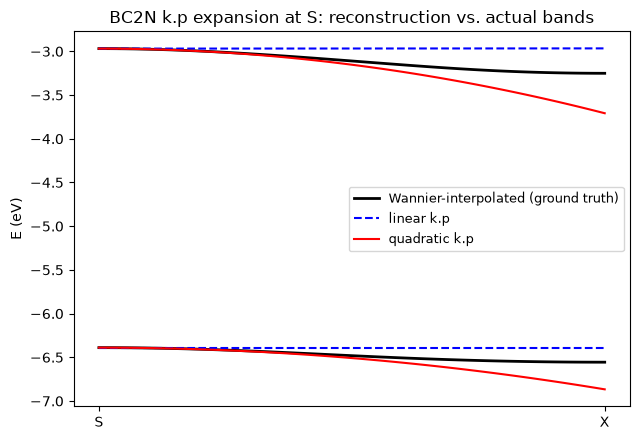

t=0.05  max|err| linear=0.0018 eV   quadratic=0.0000 eV
t=0.20  max|err| linear=0.0284 eV   quadratic=0.0013 eV
t=0.50  max|err| linear=0.1427 eV   quadratic=0.0428 eV
t=1.00  max|err| linear=0.2851 eV   quadratic=0.4568 eV


In [6]:
from waw.core.hamiltonian import interpolate_bands

X_POINT = np.array([0.5, 0.0, 0.0])
ts = np.linspace(0.0, 1.0, 101)
kpts_cut = S_POINT[None, :] + ts[:, None] * (X_POINT - S_POINT)[None, :]
bands_actual = interpolate_bands(result.hr, kpts_cut) * HARTREE_TO_EV

def reconstruct(q_cart, order2):
    H_eff = np.diag(kres.eig0.astype(np.complex128))
    H_eff = H_eff + np.einsum('a,nma->nm', q_cart, kres.first_order)
    if order2:
        H_eff = H_eff + np.einsum('a,b,nmab->nm', q_cart, q_cart, kres.second_order)
    H_eff = (H_eff + H_eff.conj().T) / 2
    return np.linalg.eigvalsh(H_eff)

q_frac = kpts_cut - S_POINT[None, :]
q_cart = q_frac @ RECIP
recon_lin = np.array([np.sort(reconstruct(q, False)) for q in q_cart]) * HARTREE_TO_EV
recon_quad = np.array([np.sort(reconstruct(q, True)) for q in q_cart]) * HARTREE_TO_EV

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for b in (1, 2):
    ax.plot(ts, bands_actual[:, b], 'k-', lw=2,
            label='Wannier-interpolated (ground truth)' if b == 1 else None)
ax.plot(ts, recon_lin[:, 0], 'b--', label='linear k.p')
ax.plot(ts, recon_lin[:, 1], 'b--')
ax.plot(ts, recon_quad[:, 0], 'r-', label='quadratic k.p')
ax.plot(ts, recon_quad[:, 1], 'r-')
ax.set_xticks([0, 1]); ax.set_xticklabels(['S', 'X'])
ax.set_ylabel('E (eV)'); ax.legend(loc='best', fontsize=9)
ax.set_title('BC2N k.p expansion at S: reconstruction vs. actual bands')
plt.tight_layout(); plt.show()

err_lin = np.abs(recon_lin - bands_actual[:, 1:3]).max(axis=1)
err_quad = np.abs(recon_quad - bands_actual[:, 1:3]).max(axis=1)
for i in (5, 20, 50, 100):
    print(f't={ts[i]:.2f}  max|err| linear={err_lin[i]:.4f} eV   quadratic={err_quad[i]:.4f} eV')

The quadratic k.p model tracks the true dispersion much more tightly than the linear-only truncation through most of the S-X segment (t=0.05 to t~0.5: error 0.0000-0.043 eV vs the linear model's 0.002-0.14 eV) -- the expected benefit of the 2nd-order, virtual-state-corrected term. Right at the far endpoint (X, t=1, half the Brillouin zone away from S) the quadratic curve actually overshoots and its error (0.457 eV) ends up LARGER than the linear model's (0.285 eV): an honestly-reported limitation of any local Taylor expansion -- a parabola cannot represent the true band flattening/turning over far from its expansion point, and eventually diverges faster than the true (bounded, periodic) dispersion. The crossover is a good reminder that a k.p model's validity radius is finite, even at 2nd order.

### 6. Full band structure for context
The 4-MLWF model's band structure along ASE's own standard k-path for this cell.

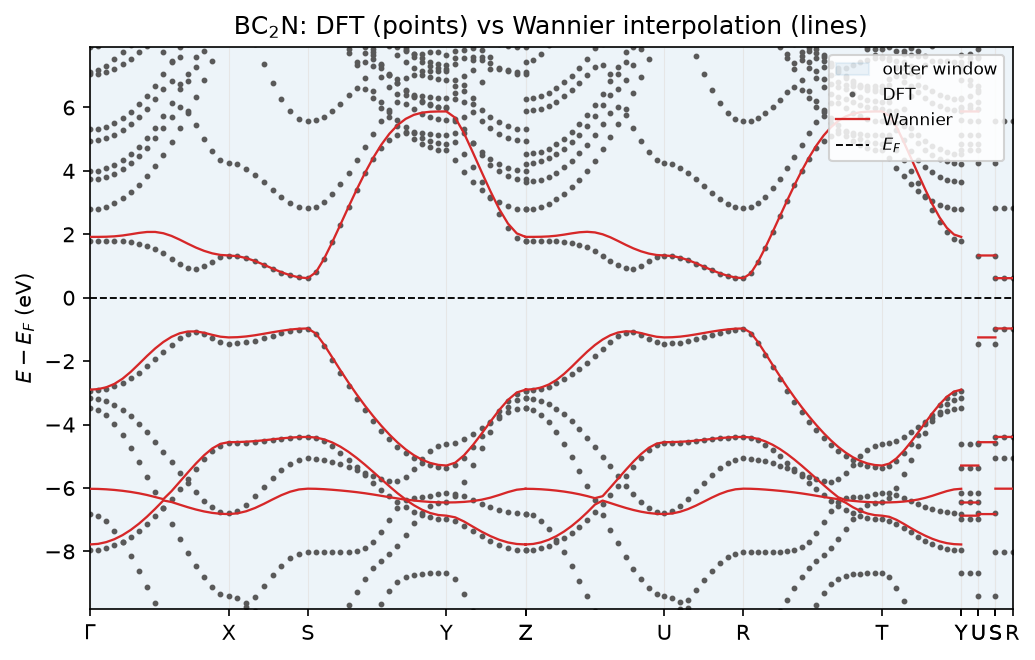

on the Wannier mesh, over ALL Wannier states (no frozen window was applied): max 1412.416 meV, rms 386.587 meV over 400 states


In [7]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'bc2n', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-15.0, 9.0), frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('BC$_2$N: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, over ALL Wannier states (no frozen window was applied): max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Cross-validation note (see `project_waw.md`'s tutorial33 entry for the full record).** The installed real `wannier90.x`/`postw90.x` (both available `quantum-espresso` modules bundle the same build) self-report version 3.1.0 but contain no trace of the `kdotp` feature at all -- `kdotp_kpoint`/`kdotp_num_bands`/`kdotp_bands` are flatly "unrecognised keywords", confirmed to be specifically a missing-feature gap (not a general input problem) by successfully running the identical `.win` with those 3 lines removed. Real `postw90.x`'s own `kdotp_0/1/2.dat` output could therefore not be directly diffed against `kdotp_coefficients`. Instead, the identical `.mmn`/`.amn`/`.eig` overlaps and energy window were fed into real `wannier90.x` to disentangle+wannierise independently; its resulting `.chk` (read via `w90chk2chk.x -export` + this project's own `read_chk_fmt`) matches waw's own $\Omega_I$, $\Omega_{\rm total}$, all 4 spreads and all 4 Wannier centres to 6 decimal places -- i.e. waw and real Wannier90 land on the exact same disentangled Wannier Hamiltonian $H(R)$ for this system. Since `kdotp_coefficients` is a deterministic function of exactly that $H(R)$, already validated independently by 5 synthetic-model unit tests (`tests/test_analysis_kdotp.py`: Hermiticity, finite-difference velocity, O(q$^3$) convergence improvement from the 2nd-order virtual-state correction, isolated-limit reduction to a plain Hessian rotation), this gives strong indirect confidence in the k.p numbers reported above even without a direct `postw90.x` diff.